In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.data_utils import MoonsDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
from utils.tree_utils import TreeHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = MoonsDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1600, 2), (400, 2), (1600,), (400,))

In [3]:
x_train.head()

,Feature_1,Feature_2
1860,1.216889,-0.627630
353,1.216012,-0.401308
1333,-0.617450,1.005901
905,1.625030,-0.216752
1289,0.798015,0.056454


In [4]:
y_train.head()

1860    1
353     1
1333    0
905     1
1289    0
Name: Class_1, dtype: int64

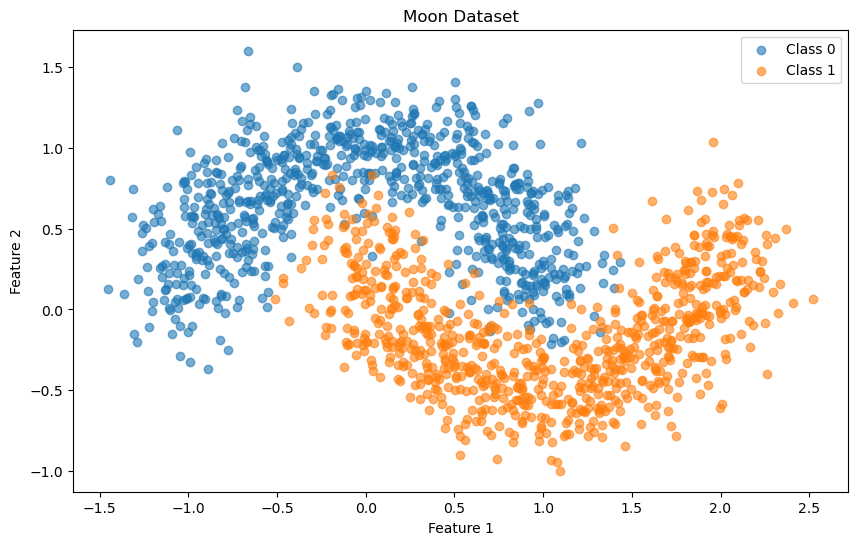

In [5]:
MoonsDataHelper.plot_moons(x_train, y_train)

## Model Training

In [6]:
class Node:
    def __init__(self, feature=None, threshold=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.value = value
        self.left = None
        self.right = None

    def append_left(self, node):
        self.left = node
    
    def append_right(self, node):
        self.right = node
    
    def split_left_right(self, data):
        left_data = data[data[self.feature] <= self.threshold]
        right_data = data[data[self.feature] > self.threshold]
        return left_data, right_data

In [7]:
def compute_impurity(data):
    if len(data) == 0:
        return 0
    
    malignant_prob = data["Class_1"].mean()
    benign_prob = 1 - malignant_prob
    
    prob_sum = malignant_prob ** 2 + benign_prob ** 2
    return 1 - prob_sum

In [8]:
def find_best_split(data, thresholds_size=20):
    prior_impurity = compute_impurity(data)
    best_split = {"gain": 0, "feature": None, "threshold": None}
        
    features = data.drop(columns=["Class_1"]).columns
    chosen_features = np.random.choice(features, size=int(np.sqrt(len(features))), replace=False)
    
    for feature in chosen_features:
        thresholds = np.linspace(start=data[feature].min(), stop=data[feature].max(), num=thresholds_size)
        
        for threshold in thresholds:
            left_data = data[data[feature] <= threshold]
            right_data = data[data[feature] > threshold]
            
            if len(left_data) == 0 or len(right_data) == 0:
                continue
            
            left_impurity = compute_impurity(left_data)
            right_impurity = compute_impurity(right_data)
            
            weighted_left_impurity = (len(left_data) / len(data)) * left_impurity
            weighted_right_impurity = (len(right_data) / len(data)) * right_impurity
            
            weighted_impurity = weighted_left_impurity + weighted_right_impurity
            gain = prior_impurity - weighted_impurity
         
            split = {"gain": gain, "feature": feature, "threshold": threshold}
            
            if gain > best_split["gain"]:
                best_split = split
            
    return best_split
        

In [9]:
def build_tree(data, max_depth=10, depth=0):
    if depth >= max_depth or len(data) <= 1:
        if len(data) == 0:
            prob = 0
        else:
            prob = data["Class_1"].mean()
        return Node(value=prob)
    
    best_split = find_best_split(data)
    if best_split["gain"] <= 0 or best_split["feature"] is None:
        prob = data["Class_1"].mean()
        return Node(value=prob)
    
    node = Node(best_split["feature"], best_split["threshold"])
    left_data, right_data = node.split_left_right(data)
    
    node.left = build_tree(left_data, max_depth, depth + 1)
    node.right = build_tree(right_data, max_depth, depth + 1)
    
    return node

In [10]:
def build_forest(forest_size=10, sample_size=50, max_tree_depth=10):
    x_train_labelled = x_train.copy()
    x_train_labelled["Class_1"] = y_train
    
    forest = []
    
    for i in range(forest_size):
        x_tree_sample =  x_train_labelled.sample(n=sample_size, replace=True)
        tree = build_tree(x_tree_sample, max_tree_depth)
        forest.append(tree)
        
        if (i + 1) % 10 == 0:
            print(f"Built {i + 1}/{forest_size} trees")
    
    return forest

In [11]:
forest = build_forest(forest_size=100, sample_size=int(0.8 * len(x_train)), max_tree_depth=7)

Built 10/100 trees
Built 20/100 trees
Built 30/100 trees
Built 40/100 trees
Built 50/100 trees
Built 60/100 trees
Built 70/100 trees
Built 80/100 trees
Built 90/100 trees
Built 100/100 trees


In [12]:
def predict_tree(node, x):
    if node.value is not None:
        return node.value >= 0.5, node.value
    if x[node.feature] <= node.threshold:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

In [13]:
def predict_tree(node, x):
    if node.value is not None:
        return node.value >= 0.5, node.value
    if x[node.feature] <= node.threshold:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

In [14]:
def predict(x):
    forest_predictions = []
    forest_probabilities = []
    
    for tree in forest:
        prediction, prob = predict_tree(tree, x)
        forest_predictions.append(prediction)
        forest_probabilities.append(prob)
    
    forest_predictions = np.array(forest_predictions)
    forest_probabilities = np.array(forest_probabilities)
    
    classes, counts = np.unique(forest_predictions, return_counts=True)
    class_mode_idx = np.argmax(counts)
    
    return classes[class_mode_idx], forest_probabilities.mean()

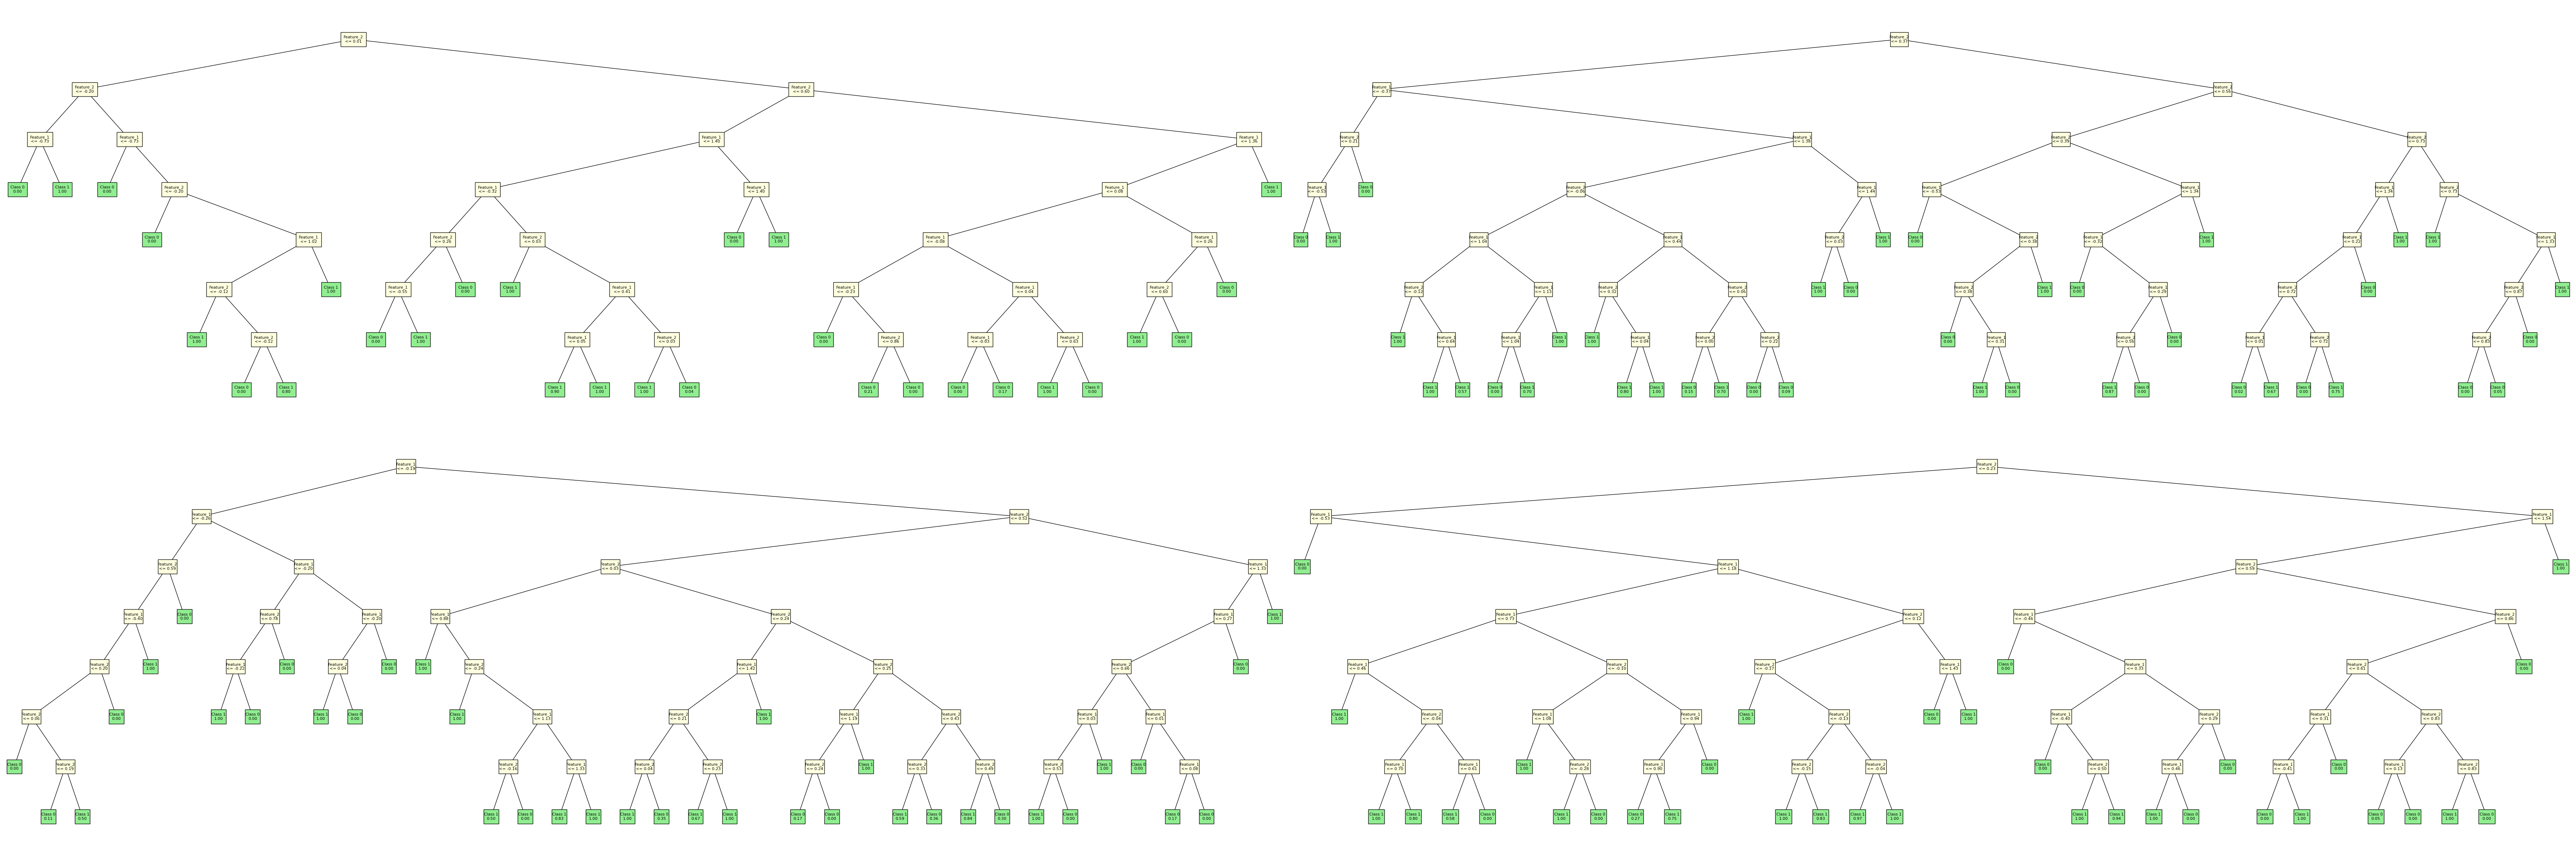

In [15]:
TreeHelper.plot_forest(forest, n_plots=4, class_names=["Class 0", "Class 1"], figsize=(72, 24))

## Model Evaluation

In [16]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    prediction, prob = predict(x)
    predictions.append(prediction)
    probabilities.append(prob)
    
predictions = np.array(predictions)
probabilities = np.array(probabilities)

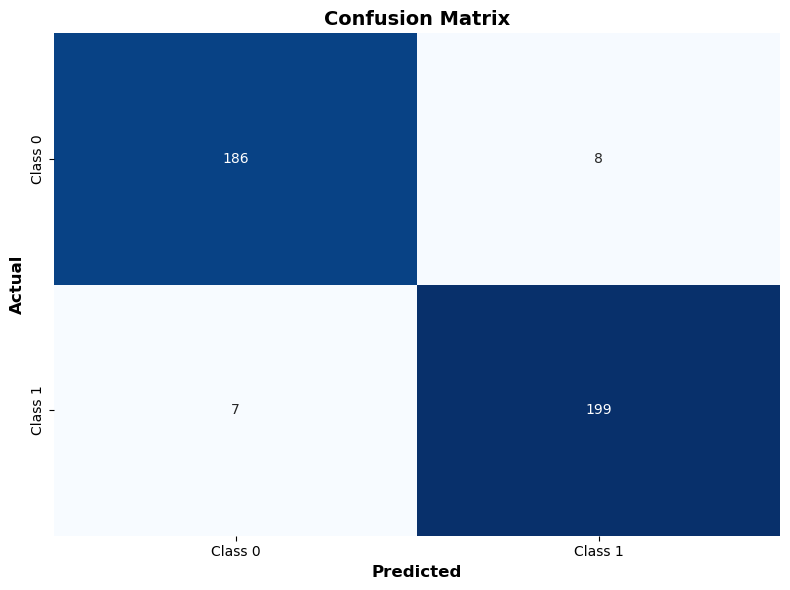

True Negatives: 186
False Positives: 8
False Negatives: 7
True Positives: 199

Sensitivity (Recall): 0.9660
Specificity: 0.9588
Precision: 0.9614
Accuracy: 0.9625
F1 Score: 0.9637


In [17]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Class 0", "Class 1"])

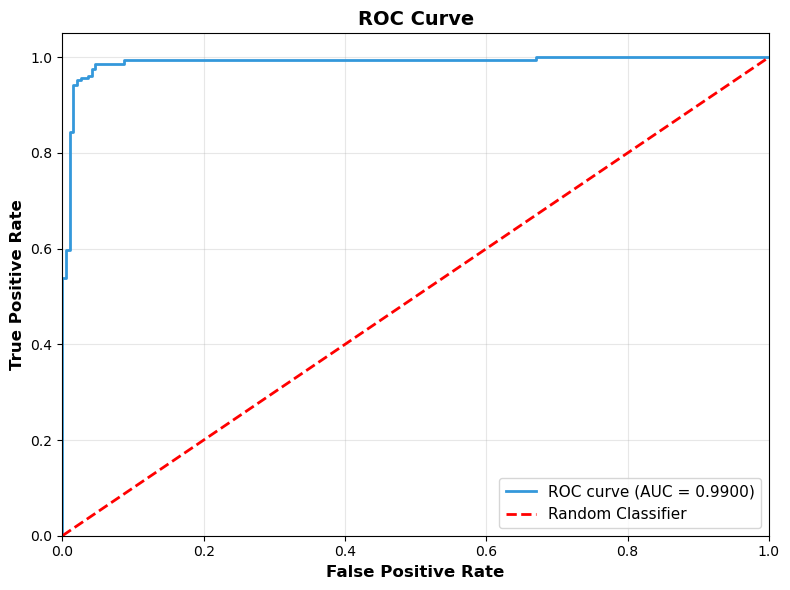

Area Under the Curve (AUC): 0.9900


In [18]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)

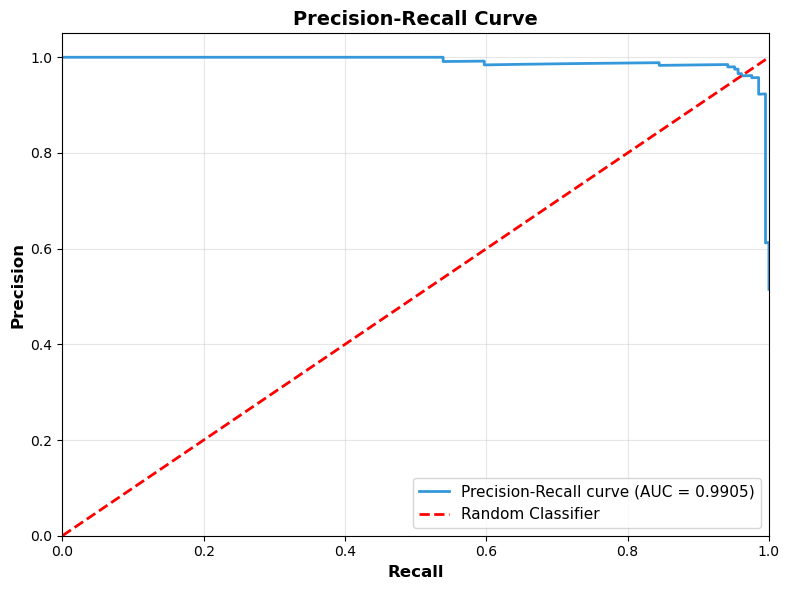

Area Under the Curve (AUC): 0.9905


In [19]:
EvaluationHelper.plot_precision_recall_curve(y_test, probabilities)

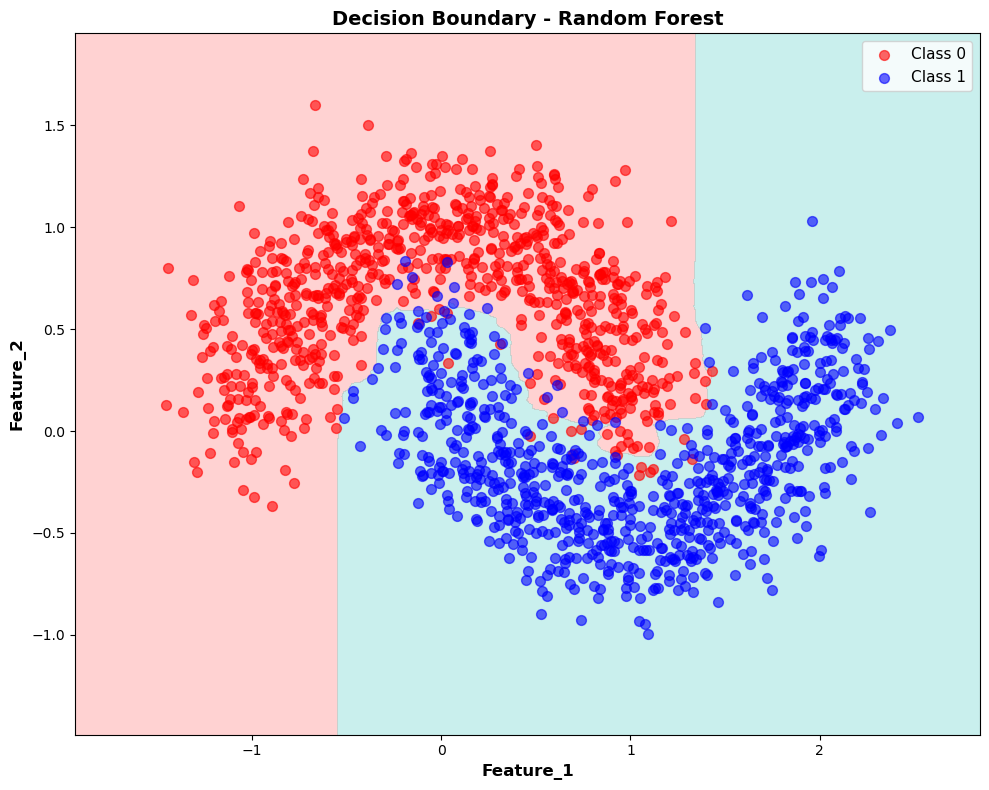

In [20]:
h = 0.02
x_min, x_max = x_test['Feature_1'].min() - 0.5, x_test['Feature_1'].max() + 0.5
y_min, y_max = x_test['Feature_2'].min() - 0.5, x_test['Feature_2'].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.array([predict(pd.Series({'Feature_1': xx[i, j], 'Feature_2': yy[i, j]}))[1] 
              for i in range(xx.shape[0]) for j in range(xx.shape[1])])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#FF6B6B', '#4ECDC4'])
ax.scatter(x_train[y_train == 0]['Feature_1'], x_train[y_train == 0]['Feature_2'], 
           c='red', marker='o', label='Class 0', alpha=0.6, s=50)
ax.scatter(x_train[y_train == 1]['Feature_1'], x_train[y_train == 1]['Feature_2'], 
           c='blue', marker='o', label='Class 1', alpha=0.6, s=50)
ax.set_xlabel('Feature_1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature_2', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary - Random Forest', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()